# Titanic Survival Analysis
Анализ данных и прогнозирование выживаемости пассажиров «Титаника» 

## Project Goal
Цель проекта: Исследование социально-демографического факторов, влияющих на выживаемость пассажиров, и построение прогностической модели с использованием алгоритмов машинного обучения.

## Data Source & Description
Источник данных: В проекте используется классический датасет Titanic - [Machine Learning from Disaster](https://www.kaggle.com/c/titanic/data) с платформы Kaggle.
Описание признаков (Data Dictionary):

Для понимания структуры данных ниже приведена расшифровка основных столбцов:

    Survived: Выживание (0 = Нет, 1 = Да) — Целевая переменная.

    Pclass: Класс билета (1, 2, 3).

    Sex: Пол пассажира.

    Age: Возраст.

    SibSp: Количество братьев/сестер или супругов на борту.

    Parch: Количество родителей или детей на борту.

    Fare: Стоимость билета.

    Embarked: Порт посадки (C = Cherbourg, Q = Queenstown, S = Southampton).

    Title: Титул (извлечен из имени на этапе предобработки).

## Import libraries
Подготовка окружения: Импорт библиотек для обработки данных(pandas, numpy), визуализации(seaborn, matplotlib) и построения моделей(scikit-learn).


In [230]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score
from sklearn.metrics import confusion_matrix
from sklearn.metrics import classification_report

## Data Loading
Загрузка данных: Первичный осмотр датасета для определения структуры признаков и выявления типов данных

In [231]:
df = pd.read_csv('../data/train.csv')
df.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [232]:
df.info()   

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [233]:
df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


## Exploratory Data Analysis (EDA)
Исследовательский анализ данных: Поиск скрытых закономерностей, визуализация распределений и оценка качества данных(пропусков).

### Missing Data Visualization
Анализ пропущенных данных: Визуализация «дыр» в данных. Тепловая карта помогает определить стратегию заполнения пропусков или целесообразность удаления признаков(как в случае с Cabin) 

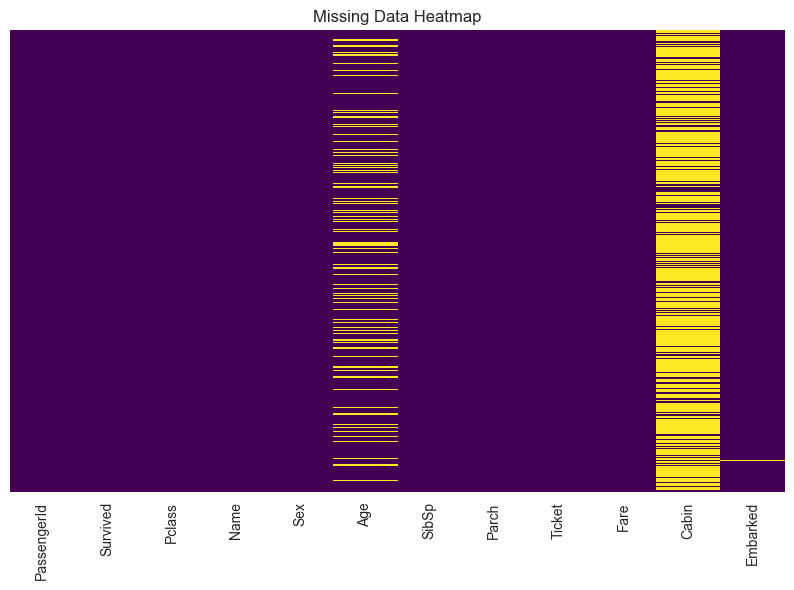

In [234]:
plt.figure(figsize=(10, 6))
sns.heatmap(df.isnull(), yticklabels=False, cbar=False, cmap='viridis')
plt.title('Missing Data Heatmap')
plt.savefig('../images/missing_data.png', dpi=300, bbox_inches='tight')
plt.show()

### Survival Distribution
Баланс классов: Анализ целевой переменной. Позволяет понять общее соотношение выживших и погибших, что критично для выбора метрик оценки будущей модели.

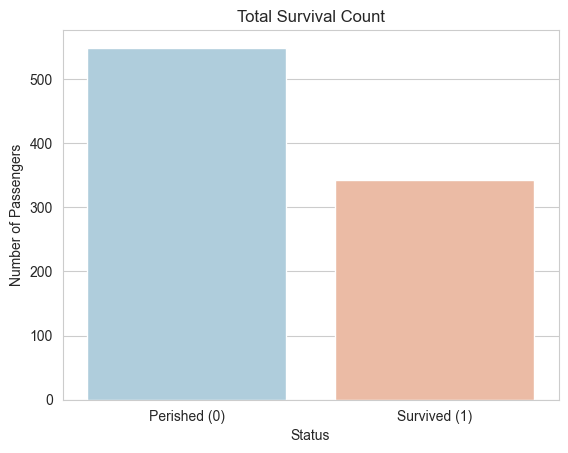

In [235]:
sns.set_style('whitegrid')
ax = sns.countplot(x='Survived', data=df, hue='Survived', palette='RdBu_r', legend=False)
ax.set_xticks([0, 1])
ax.set_xticklabels(['Perished (0)', 'Survived (1)'])

plt.xlabel('Status')
plt.ylabel('Number of Passengers')
plt.title('Total Survival Count')

plt.show()

### Survival by Gender
Влияние пола: Проверка гипотезы о приоритетной эвакуации женщин. Этот признак традиционно является одним из самых сильных предикторов в данной задаче

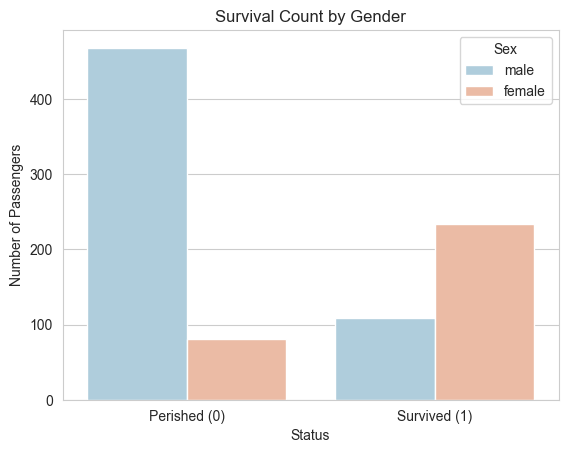

In [236]:
sns.set_style('whitegrid')
ax = sns.countplot(x='Survived', hue='Sex', data=df, palette='RdBu_r')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Perished (0)', 'Survived (1)'])

plt.title('Survival Count by Gender')
plt.xlabel('Status')
plt.ylabel('Number of Passengers')

plt.show()

### Survival by Passenger Class
Социально-экономический фактор: Анализ выживаемости в зависимости от класса каюты. Визуализация подтверждает гипотезу о том, что статус пассажира влиял на шансы спасения.

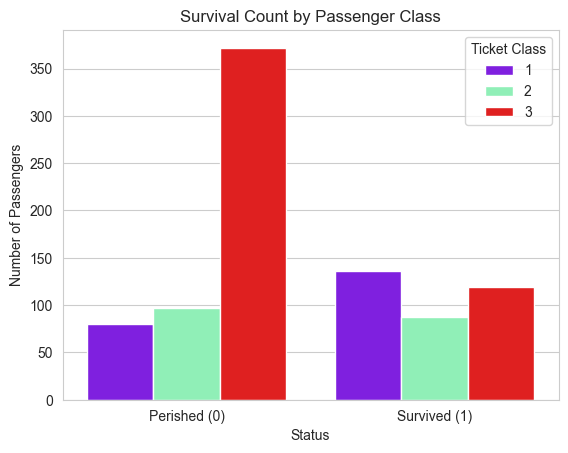

In [237]:
sns.set_style('whitegrid')
ax = sns.countplot(x='Survived', hue='Pclass', data=df, palette='rainbow')
ax.set_xticks([0, 1])
ax.set_xticklabels(['Perished (0)', 'Survived (1)'])

plt.title('Survival Count by Passenger Class')
plt.xlabel('Status')
plt.ylabel('Number of Passengers')
plt.legend(title='Ticket Class', loc='upper right')

plt.show()

### Age Distribution
Демографический профиль: Анализ возрастных групп. Помогает понять возрастную структуру пассажиров и обосновать выбор медианы для заполнения пропущенных значений.

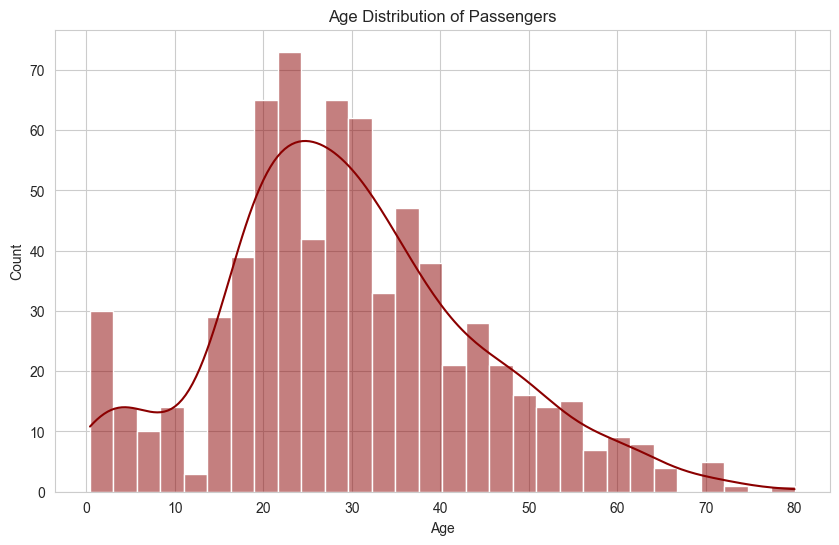

In [238]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Age'].dropna(), kde=True, color='darkred', bins=30)

plt.title('Age Distribution of Passengers')
plt.xlabel('Age')
plt.ylabel('Count')
plt.show()

### Family Size Impact
Влияние семейных связей: Создание производного признака FamilySize. Мы проверяем, как наличие родственников (одиночки против семей) коррелирует с шансами на выживание.

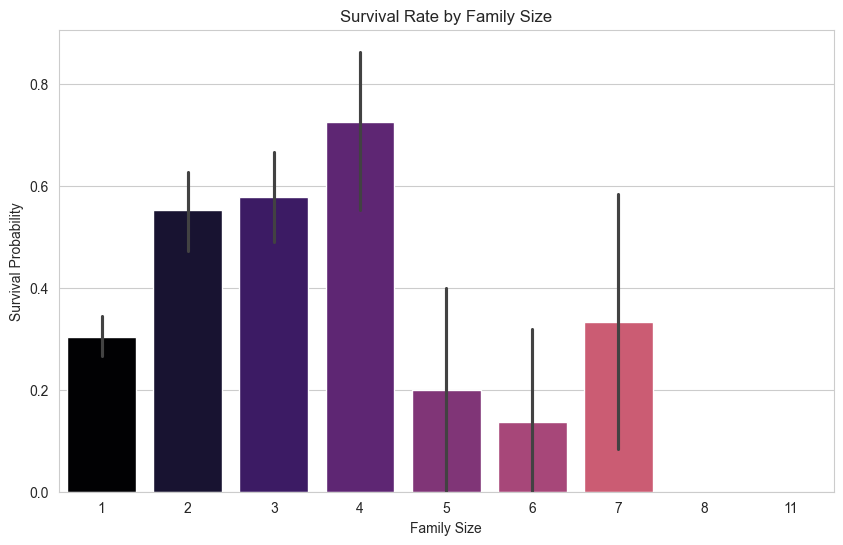

In [239]:
df['FamilySize'] = df['SibSp'] + df['Parch'] + 1

plt.figure(figsize=(10, 6))
sns.barplot(data=df, x='FamilySize', y='Survived', hue='FamilySize', palette='magma', legend=False)

plt.title('Survival Rate by Family Size')
plt.xlabel('Family Size')
plt.ylabel('Survival Probability')

plt.show()

### Feature Correlation
Исследование взаимосвязи признаков: Тепловая карта помогает понять, какие числовые параметры сильнее всего связаны с выживаемостью.

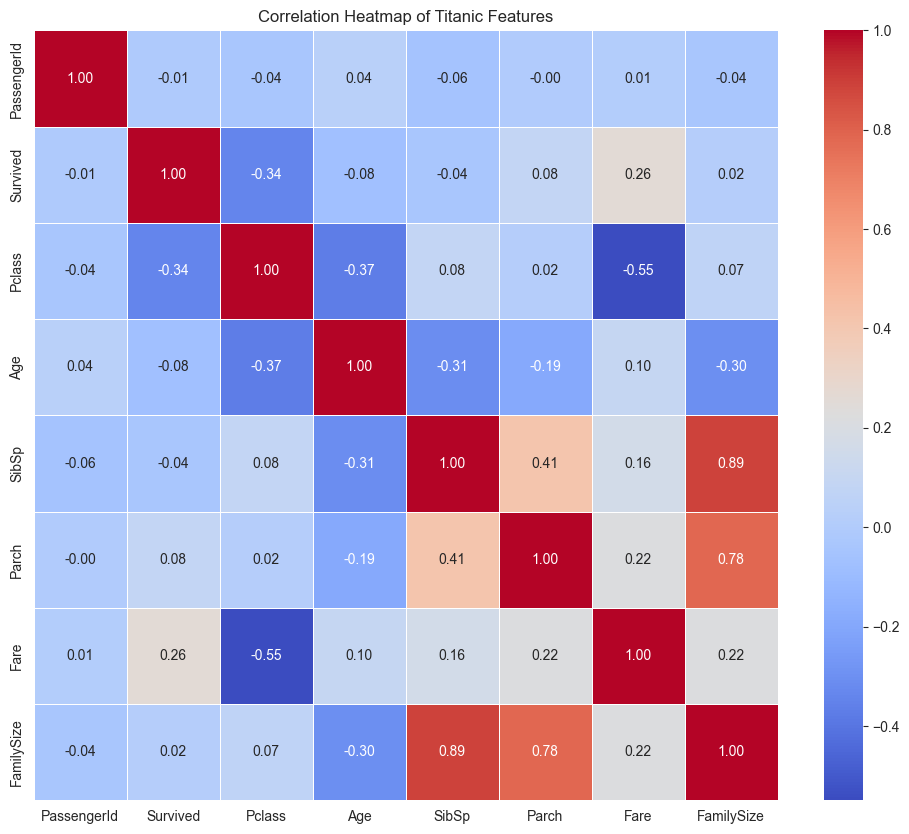

In [240]:
plt.figure(figsize=(12, 10))

numeric_df = df.select_dtypes(include=[np.number])
sns.heatmap(numeric_df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)

plt.title('Correlation Heatmap of Titanic Features')
plt.savefig('../images/correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

## Data Preparation
Предобработка данных: Очистка датасета и инженерия признаков (Feature Engineering). На этом этапе мы переводим сырые данные в формат, пригодный для обучения модели.

    Imputation: Заполнение пропусков в Age и Embarked.

    Feature Engineering: Создание признака IsAlone и извлечение титулов (Title) из имен.

    Dimensionality Reduction: Удаление неинформативных признаков (Name, Ticket и др.), создающих лишний шум.

In [241]:
# 1. Заполнение пропусков
# Используем медиану для возраста и моду для порта посадки
df['Age'] = df['Age'].fillna(df['Age'].median())
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

# 2. Создание признака IsAlone
# На основе уже созданного FamilySize определяем, ехал ли пассажир один
df['IsAlone'] = np.where(df['FamilySize'] == 1, 1, 0)

# 3. Извлечение титулов (Title) из имен
# Регулярное выражение находит обращения (Mr., Mrs. и т.д.)
titles = r'(?:,\s|\s+)(Mr\.|Mrs\.|Miss\.|Master\.|Dr\.|Rev\.|Col\.|Major\.|Lady\.|Sir\.|Capt\.)(?:\s|$)'
df['Title'] = df['Name'].str.extract(titles)

# Группируем редкие титулы в категорию 'Rare', чтобы избежать переобучения
rare_titles = df['Title'].value_counts()[df['Title'].value_counts() < 10].index
df.loc[df['Title'].isin(rare_titles), 'Title'] = 'Rare'

# 4. Удаление лишних колонок
# Убираем идентификаторы и текст, который не поможет модели найти закономерности
df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True, errors='ignore')

df.head()

,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,Embarked,FamilySize,IsAlone,Title
0,0,3,male,22.0,1,0,7.2500,S,2,0,Mr.
1,1,1,female,38.0,1,0,71.2833,C,2,0,Mrs.
2,1,3,female,26.0,0,0,7.9250,S,1,1,Miss.
3,1,1,female,35.0,1,0,53.1000,S,2,0,Mrs.
4,0,3,male,35.0,0,0,8.0500,S,1,1,Mr.


## Feature Encoding
Кодирование признаков: Преобразование категориальных переменных в числовые векторы с помощью One-Hot Encoding (get_dummies). Это необходимо, так как большинство алгоритмов работают только с числами.

In [242]:
df = pd.get_dummies(df, columns=['Sex', 'Embarked', 'Pclass', 'Title'], dtype=int)

df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 20 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Survived       891 non-null    int64  
 1   Age            891 non-null    float64
 2   SibSp          891 non-null    int64  
 3   Parch          891 non-null    int64  
 4   Fare           891 non-null    float64
 5   FamilySize     891 non-null    int64  
 6   IsAlone        891 non-null    int64  
 7   Sex_female     891 non-null    int64  
 8   Sex_male       891 non-null    int64  
 9   Embarked_C     891 non-null    int64  
 10  Embarked_Q     891 non-null    int64  
 11  Embarked_S     891 non-null    int64  
 12  Pclass_1       891 non-null    int64  
 13  Pclass_2       891 non-null    int64  
 14  Pclass_3       891 non-null    int64  
 15  Title_Master.  891 non-null    int64  
 16  Title_Miss.    891 non-null    int64  
 17  Title_Mr.      891 non-null    int64  
 18  Title_Mrs.     891 no

## Model Training & Evaluation
Обучение и валидация: Построение прогнозной модели.

### Data Splitting
Валидация: Разделение данных на обучающую и тестовую выборки (80/20). Это позволяет проверить модель на данных, которые она «не видела», и избежать переобучения.

In [243]:
X = df.drop('Survived', axis=1)
y = df['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

### Random Forest Classifier
Выбор модели: Использование ансамблевого алгоритма «Случайный лес». Данная модель устойчива к выбросам и хорошо выявляет нелинейные зависимости.

In [244]:
rf_model = RandomForestClassifier(n_estimators=100, max_depth=5, random_state=42)
rf_model.fit(X_train, y_train)

predictions = rf_model.predict(X_test)

import joblib
joblib.dump(rf_model, '../models/titanic_rf_model.pkl')

print(f"Model Accuracy: {accuracy_score(y_test, predictions):.2%}")

print("\nClassification Report:")
print(classification_report(y_test, predictions))

Model Accuracy: 82.68%

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86       105
           1       0.81      0.76      0.78        74

    accuracy                           0.83       179
   macro avg       0.82      0.82      0.82       179
weighted avg       0.83      0.83      0.83       179



## Confusion Matrix Visualization
Оценка качества: Матрица ошибок позволяет детально разобрать, где именно модель ошибается: сколько выживших были ошибочно признаны погибшими (False Negatives) и наоборот.

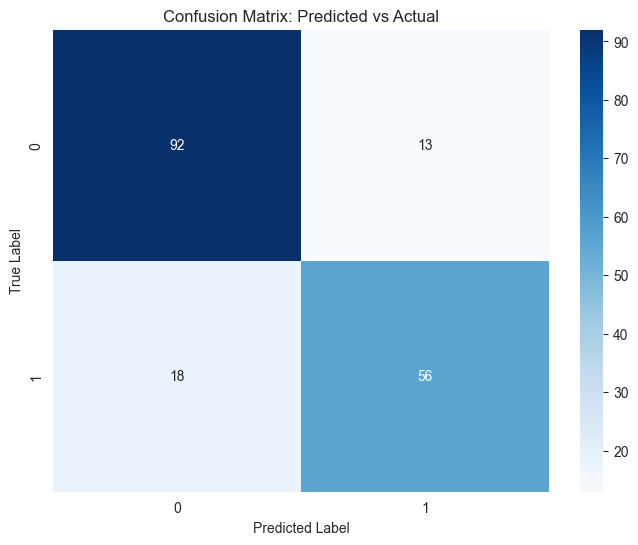

In [245]:
plt.figure(figsize=(8, 6))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='Blues')

plt.title('Confusion Matrix: Predicted vs Actual')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.savefig('../images/confusing_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

## Conclusion: Feature Importance
Интерпретация модели: Анализ важности признаков (Feature Importance). Этот этап позволяет      
«открыть черный ящик» модели и увидеть, на какие именно данные опирался алгоритм при принятии решений.

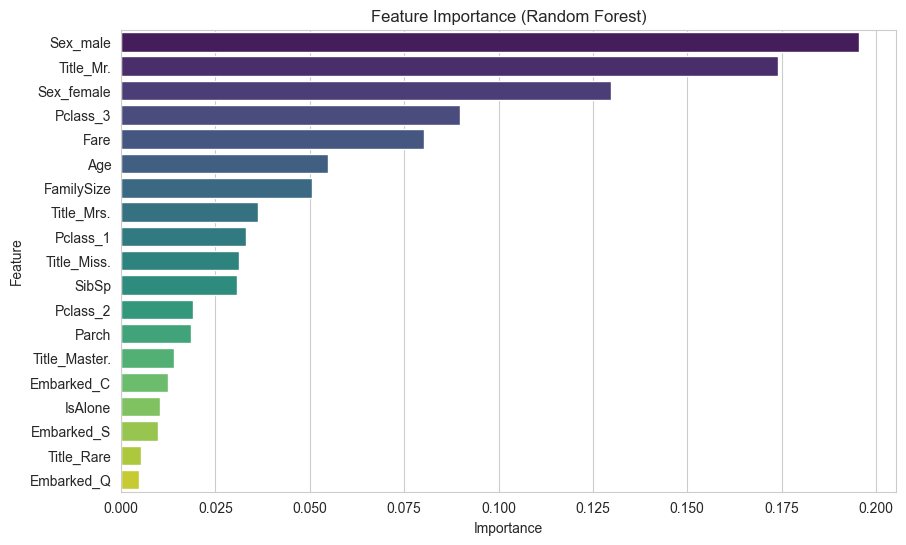

In [246]:
importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
}).sort_values(by='Importance', ascending=False)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=importances,hue='Feature', palette='viridis')
plt.title('Feature Importance (Random Forest)')
plt.savefig('../images/feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

## Final Predictions (Submission)
Применение обученной модели к тестовому набору данных для генерации финальных предсказаний.

In [247]:
test_df = pd.read_csv('../data/test.csv')
passenger_ids = test_df['PassengerId']

test_df['Age'] = test_df['Age'].fillna(test_df['Age'].median())
test_df['Fare'] = test_df['Fare'].fillna(test_df['Fare'].median())
test_df['Embarked'] = test_df['Embarked'].fillna(test_df['Embarked'].mode()[0])

test_df['FamilySize'] = test_df['SibSp'] + test_df['Parch'] + 1
test_df['IsAlone'] = np.where(test_df['FamilySize'] == 1, 1, 0)
test_df['Title'] = test_df['Name'].str.extract(titles)
test_df.loc[test_df['Title'].isin(rare_titles), 'Title'] = 'Rare'

test_df.drop(columns=['PassengerId', 'Name', 'Ticket', 'Cabin'], inplace=True, errors='ignore')

test_encoded = pd.get_dummies(test_df, columns=['Sex', 'Embarked', 'Pclass', 'Title'], dtype=int)

test_encoded = test_encoded.reindex(columns=X.columns, fill_value=0)

final_preds = rf_model.predict(test_encoded)

submission = pd.DataFrame({
    "PassengerId": passenger_ids,
    "Survived": final_preds
})

submission.to_csv('../results/submission.csv', sep = ';', index=False)
print("Файл с предсказаниями успешно сохранен в /results/submission.csv")

Файл с предсказаниями успешно сохранен в /results/submission.csv


## Conclusion
В ходе работы над моим первым проектом в Data Science я проанализировал данные пассажиров Титаника и обучил модель случайного леса (Random Forest). Вот основные выводы:
    
    Что больше всего повлияло на выживание: График важности признаков подтвердил исторические факты. Самыми важными факторами оказались пол (женщины выживали чаще), социальный статус (обращение в имени, например, "Mr" или "Mrs") и класс билета (пассажиры 1-го класса имели приоритет).

    Результат модели: Модель предсказывает выживаемость с точностью ~82%. Это хороший показатель для базовой настройки алгоритма.

    Зачем мы меняли данные: Создание новых признаков, таких как «Размер семьи» и «Титул», помогло модели лучше понять структуру данных и повысило точность предсказаний.

    Что можно улучшить: В будущем точность можно поднять, если более детально поработать с возрастом пассажиров или попробовать более сложные алгоритмы (например, градиентный бустинг).